In [21]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [22]:
# Step 2: Load and Clean Dataset
# The CSV has two extra Yahoo Finance header rows, so skip them.
df = pd.read_csv("Google_Stock_Price.csv", skiprows=[1, 2])
df = df.rename(columns={"Price": "Date"})

df["Date"] = pd.to_datetime(df["Date"])
df["Open"] = pd.to_numeric(df["Open"], errors="coerce")
df = df.dropna(subset=["Open"]).sort_values("Date").reset_index(drop=True)

prices = df["Open"].astype("float32").to_numpy()
df[["Date", "Open"]].head()

,Date,Open
0,2020-01-02 00:00:00+00:00,67.420502
1,2020-01-03 00:00:00+00:00,67.400002
2,2020-01-06 00:00:00+00:00,67.581497
3,2020-01-07 00:00:00+00:00,70.023003
4,2020-01-08 00:00:00+00:00,69.740997


In [23]:
# Step 3: Create Return Sequences
# Predicting daily log-return is more stable than predicting the raw price level.
lookback = 60
train_size = int(len(prices) * 0.8)
log_returns = np.diff(np.log(prices))

X, y, target_indices = [], [], []
for i in range(lookback, len(log_returns)):
    X.append(log_returns[i - lookback:i])
    y.append(log_returns[i])
    target_indices.append(i + 1)

X = np.array(X)
y = np.array(y)
target_indices = np.array(target_indices)

train_mask = target_indices < train_size
test_mask = target_indices >= train_size

print("Total prices:", len(prices))
print("Training targets:", train_mask.sum())
print("Testing targets:", test_mask.sum())

Total prices: 1258
Training targets: 945
Testing targets: 252


In [24]:
# Step 4: Scale Input Sequences
return_scaler = StandardScaler()

X_train = return_scaler.fit_transform(X[train_mask].reshape(-1, 1)).reshape(-1, lookback, 1)
X_test = return_scaler.transform(X[test_mask].reshape(-1, 1)).reshape(-1, lookback, 1)

y_train = y[train_mask]
y_test = y[test_mask]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(945, 60, 1) (945,)
(252, 60, 1) (252,)


In [25]:
# Step 5: Build LSTM Model
model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(32, return_sequences=True),
    Dropout(0.1),
    LSTM(16),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Step 6: Train Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

In [27]:
# Step 7: Evaluate Model
predicted_returns = model.predict(X_test, verbose=0).flatten()

test_indices = target_indices[test_mask]
real = prices[test_indices]
previous_day = prices[test_indices - 1]
predicted = previous_day * np.exp(predicted_returns)

mse = mean_squared_error(real, predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(real, predicted)
r2 = r2_score(real, predicted)

baseline_mse = mean_squared_error(real, previous_day)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(real, previous_day)
baseline_r2 = r2_score(real, previous_day)

print("Evaluation on chronological test set:")
print(f"Model MSE: {mse:.4f}")
print(f"Model RMSE: {rmse:.4f}")
print(f"Model MAE: {mae:.4f}")
print(f"Model R2 Score: {r2:.4f}")
print()
print("Previous-day baseline:")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Baseline R2 Score: {baseline_r2:.4f}")

Evaluation on chronological test set:
Model MSE: 10.9197
Model RMSE: 3.3045
Model MAE: 2.2994
Model R2 Score: 0.9536

Previous-day baseline:
Baseline RMSE: 3.2090
Baseline MAE: 2.1769
Baseline R2 Score: 0.9563


In [28]:
# Step 8: Prediction Comparison
comparison = pd.DataFrame({
    "Date": df.loc[test_indices, "Date"].dt.date.to_numpy(),
    "Actual": real,
    "Predicted": predicted,
    "Previous Day": previous_day
}).round(2)

comparison.head(10)

,Date,Actual,Predicted,Previous Day
0,2024-01-02,138.550003,139.770004,139.630005
1,2024-01-03,137.250000,138.669998,138.550003
2,2024-01-04,138.419998,137.300003,137.250000
3,2024-01-05,136.750000,138.210007,138.419998
4,2024-01-08,136.289993,136.440002,136.750000
5,2024-01-09,138.500000,135.910004,136.289993
6,2024-01-10,141.000000,137.800003,138.500000
7,2024-01-11,143.490005,139.919998,141.000000
8,2024-01-12,142.669998,142.169998,143.490005
9,2024-01-16,142.000000,141.619995,142.669998


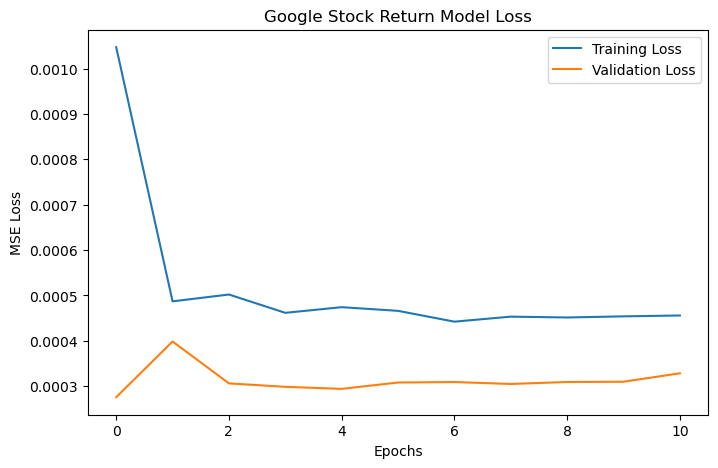

In [29]:
# Step 9: Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Google Stock Return Model Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

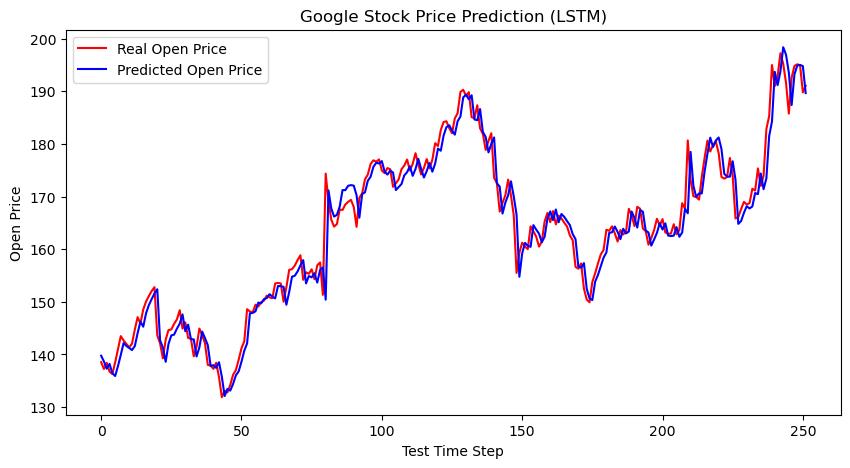

In [30]:
# Step 10: Plot Actual vs Predicted Prices
plt.figure(figsize=(10, 5))
plt.plot(real, color='red', label='Real Open Price')
plt.plot(predicted, color='blue', label='Predicted Open Price')
plt.title("Google Stock Price Prediction (LSTM)")
plt.xlabel("Test Time Step")
plt.ylabel("Open Price")
plt.legend()
plt.show()